We’ll analyse data divided by regions.

#### **0. Importing data**

In [1]:
# Import necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Setting the path to the dataset
PATH = "../survey_results_public.csv"

In [3]:
# Loading the dataset into a DataFrame
df = pd.read_csv(PATH)

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\3191969852.py:2: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


In [4]:
# Displaying the first few rows of the DataFrame
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


#### **1. General analysis**

In [5]:
# Setting the maximum number of rows to display
pd.options.display.max_rows = 4000

In [6]:
# Displaying the shape of the DataFrame
df.shape

(49191, 172)

In the survey took place 49191 responders. 

In [7]:
# Displaying the information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [8]:
# Displaying the statistical summary of the DataFrame
df.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


Some columns have a lot of outliers, f.e. 100 years of experience. It will be investigated later.

In [9]:
# Checking for missing values in the DataFrame
df.isnull().sum()

ResponseId                                      0
MainBranch                                      0
Age                                             0
EdLevel                                      1042
Employment                                    852
EmploymentAddl                               4316
WorkExp                                      6298
LearnCodeChoose                              2333
LearnCode                                   15635
LearnCodeAI                                  3990
AILearnHow                                  20934
YearsCode                                    6149
DevType                                      5511
OrgSize                                     15013
ICorPM                                      15948
RemoteWork                                  15411
PurchaseInfluence                           11754
TechEndorseIntro                            11635
TechEndorse_1                               13216
TechEndorse_2                               13216


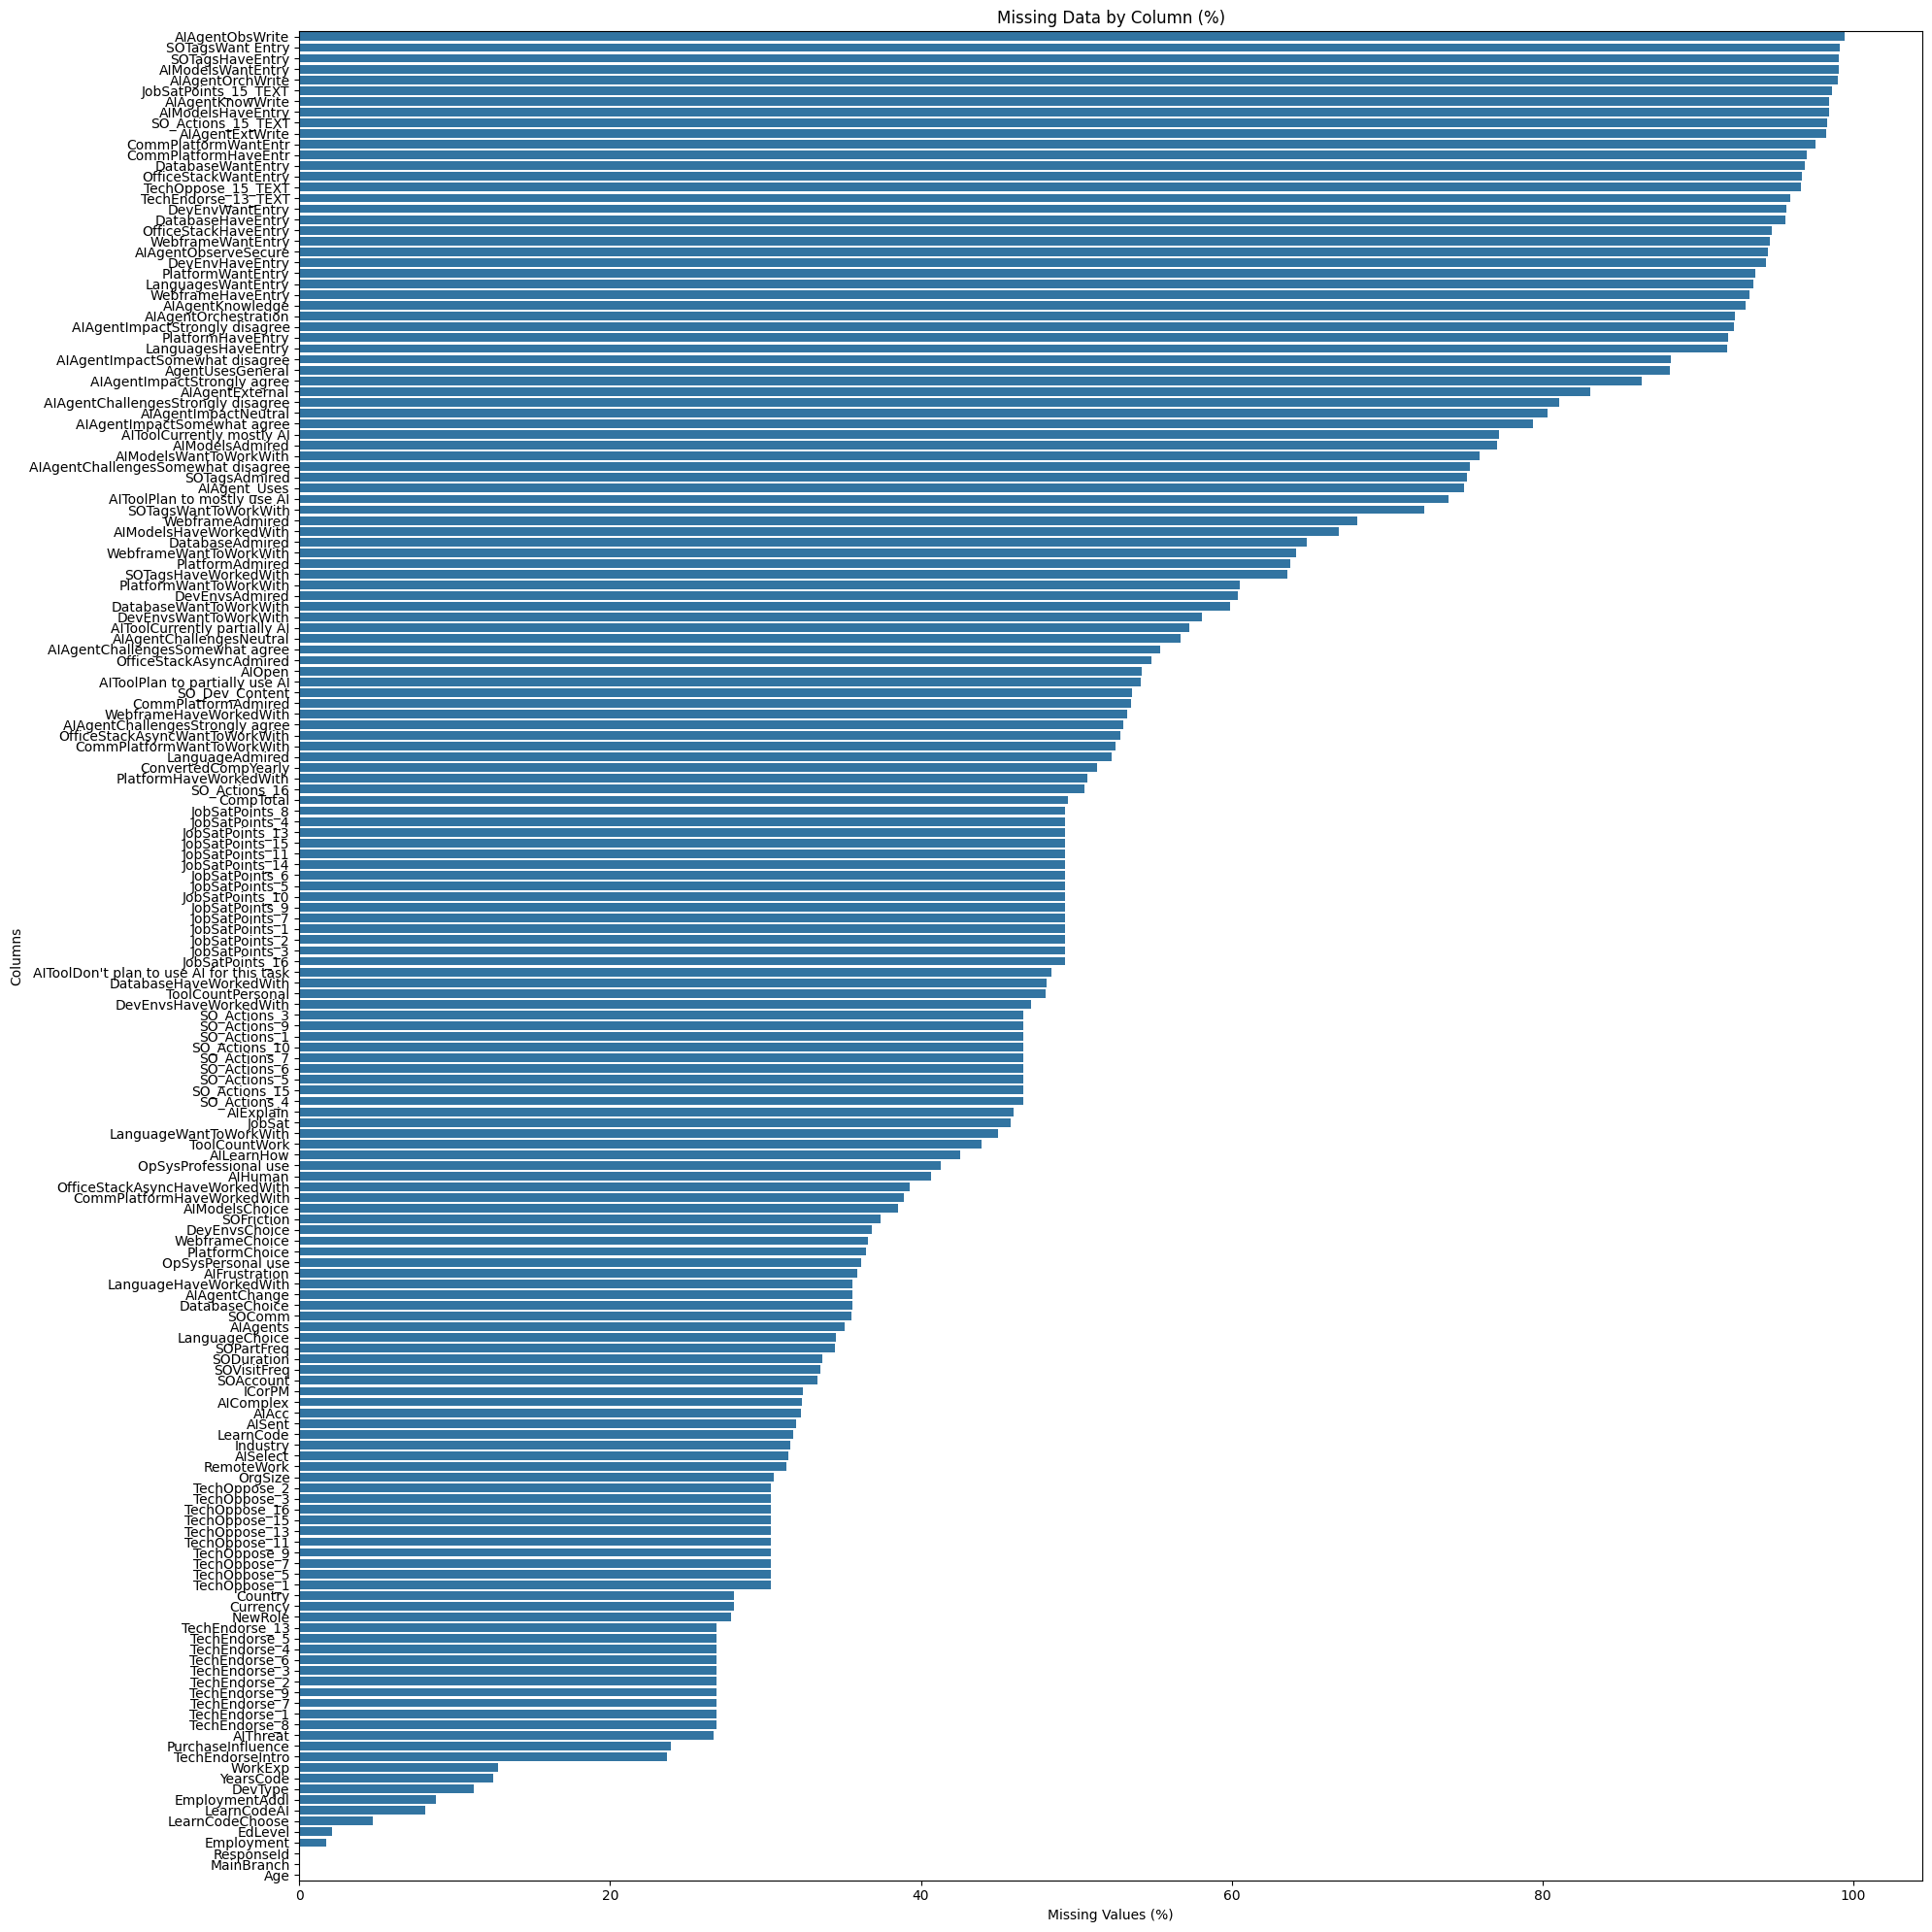

In [10]:
# Calculating the percentage of missing values for each column
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(20, 20))

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")
plt.title("Missing Data by Column (%)")
plt.tight_layout()
plt.show()

A lot of columns have more than 50% of missing data. Target column has as well around 50% of missing values. They will be deleted.

There are two mandatory columns: main branch and age.

#### **2. Preparing the data**

In [11]:
# Creating a new DataFrame for EDA by dropping rows with missing values in the target column
df_eda = df.dropna(subset=["ConvertedCompYearly"])
df_eda.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [12]:
# Displaying the shape of the filtered DataFrame
df_eda.shape

(23947, 172)

Half the data was deleted due to missing target value.

In [13]:
# Checking for missing values in the "Country" column of the filtered DataFrame
df_eda["Country"].isna().sum()

np.int64(0)

So all missing data in "Country" column were cleaned.

In [14]:
# Displaying countries list
df["Country"].value_counts()

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Brazil                                                   825
Australia                                                804
Spain                                                    717
Sweden                                                   616
Switzerland                                              546
Czech Republic                                           520
Austria         

In [15]:
# Mapping countries to regions based on the United Nations geoscheme modified by business logic for better grouping in the context of the survey analysis
def map_region(country):
    # -------- EUROPE --------
    if country in ["Germany", "Austria", "Switzerland"]:
        return "DACH"
    
    elif country in ["United Kingdom of Great Britain and Northern Ireland", "Ireland", "Isle of Man"]:
        return "UK & Ireland"
    
    elif country in ["France", "Belgium", "Netherlands", "Luxembourg"]:
        return "Western Europe"
    
    elif country in ["Sweden", "Norway", "Denmark", "Finland", "Iceland"]:
        return "Nordics"
    
    elif country in ["Italy", "Spain", "Portugal", "Greece", "Malta", "Cyprus", "Andorra", "San Marino"]:
        return "Southern Europe"
    
    elif country in [
        "Poland", "Czech Republic", "Slovakia", "Hungary", "Romania", "Bulgaria",
        "Ukraine", "Serbia", "Croatia", "Slovenia", "Lithuania", "Latvia",
        "Estonia", "Bosnia and Herzegovina", "Albania", "Montenegro",
        "Republic of North Macedonia", "Belarus", "Moldova", "Republic of Moldova",
        "Kosovo", "Russian Federation"
    ]:
        return "CEE"
    
    # -------- NORTH AMERICA --------
    elif country in ["United States of America", "Canada"]:
        return "North America"
    
    # -------- LATIN AMERICA --------
    elif country in [
        "Mexico", "Guatemala", "Costa Rica", "Panama", "Dominican Republic",
        "Cuba", "Jamaica", "Trinidad and Tobago", "Honduras", "El Salvador",
        "Nicaragua", "Belize", "Barbados", "Saint Lucia", "Antigua and Barbuda", "Haiti"
    ]:
        return "Central America & Caribbean"
    
    elif country in [
        "Brazil", "Argentina", "Colombia", "Chile", "Peru", "Uruguay",
        "Venezuela, Bolivarian Republic of...", "Ecuador", "Paraguay",
        "Bolivia", "Guyana", "Suriname"
    ]:
        return "South America"
    
    # -------- ASIA --------
    elif country in ["India", "Pakistan", "Bangladesh", "Sri Lanka", "Nepal", "Afghanistan", "Maldives", "Bhutan"]:
        return "South Asia"
    
    elif country in [
        "China", "Japan", "South Korea", "Republic of Korea",
        "Democratic People's Republic of Korea", "North Korea",
        "Taiwan", "Hong Kong (S.A.R.)", "Mongolia"
    ]:
        return "East Asia"
    
    elif country in [
        "Indonesia", "Viet Nam", "Philippines", "Thailand",
        "Malaysia", "Singapore", "Myanmar", "Cambodia",
        "Lao People's Democratic Republic", "Brunei Darussalam",
        "Timor-Leste"
    ]:
        return "Southeast Asia"
    
    elif country in [
        "Iran, Islamic Republic of...", "Israel", "Turkey",
        "United Arab Emirates", "Saudi Arabia", "Jordan",
        "Lebanon", "Iraq", "Kuwait", "Qatar", "Bahrain",
        "Oman", "Yemen", "Palestine", "Syrian Arab Republic",
        "Georgia", "Armenia", "Azerbaijan"
    ]:
        return "Middle East"
    
    elif country in ["Kazakhstan", "Uzbekistan", "Kyrgyzstan", "Tajikistan", "Turkmenistan"]:
        return "Central Asia"
    
    # -------- AFRICA --------
    elif country in [
        "Morocco", "Algeria", "Tunisia", "Egypt", "Libyan Arab Jamahiriya", "Sudan"
    ]:
        return "North Africa"
    
    elif country in [
        "Nigeria", "Ghana", "Senegal", "Côte d'Ivoire", "Benin",
        "Togo", "Mali", "Niger", "Burkina Faso", "Guinea",
        "Guinea-Bissau", "Sierra Leone", "Liberia", "Gambia",
        "Cape Verde", "Mauritania"
    ]:
        return "West Africa"
    
    elif country in [
        "Kenya", "Ethiopia", "Uganda", "United Republic of Tanzania",
        "Rwanda", "Burundi", "Somalia", "Djibouti", "Eritrea"
    ]:
        return "East Africa"
    
    elif country in [
        "Cameroon", "Democratic Republic of the Congo",
        "Congo, Republic of the...", "Gabon",
        "Central African Republic", "Chad", "Equatorial Guinea"
    ]:
        return "Central Africa"
    
    elif country in [
        "South Africa", "Zimbabwe", "Zambia", "Namibia",
        "Botswana", "Mozambique", "Lesotho", "Eswatini", "Swaziland",
        "Angola", "Malawi", "Madagascar", "Mauritius"
    ]:
        return "Southern Africa"
    
    # -------- OCEANIA --------
    elif country in [
        "Australia", "New Zealand", "Fiji", "Papua New Guinea",
        "Micronesia, Federated States of...", "Palau"
    ]:
        return "Oceania"
    
    # -------- SPECIAL --------
    elif country == "Nomadic":
        return "Other"
    

    # -------- FINAL FALLBACK --------
    else:
        return "Other"

In [16]:
# Applying the mapping function to create a new "Region" column in the DataFrame
df_eda["Region"] = df_eda["Country"].apply(map_region)

In [17]:
# Displaying the value counts of the "Region" column to verify the mapping
df_eda["Region"].value_counts()

Region
North America                  6158
CEE                            2929
DACH                           2839
Western Europe                 1881
UK & Ireland                   1649
Southern Europe                1575
South Asia                     1465
South America                  1198
Nordics                        1083
Oceania                         752
Middle East                     624
East Asia                       401
Southeast Asia                  395
Central America & Caribbean     307
Southern Africa                 237
West Africa                     141
North Africa                    130
East Africa                     123
Central Asia                     34
Central Africa                   14
Other                            12
Name: count, dtype: int64

In [18]:
# Displaying the value counts of countries categorized as "Other" to understand which countries are included in this category
df_eda[df_eda["Region"] == "Other"]["Country"].value_counts()

Country
Nomadic    12
Name: count, dtype: int64

We have 12 responses that has country stated as "Nomadic". Probably people don't live in one country and are freelancers. Will investigate later.

In [19]:
# Filtering out the top 5% of salaries to avoid skewing the boxplot
threshold = df_eda["ConvertedCompYearly"].quantile(0.95)

df_plot = df_eda[df_eda["ConvertedCompYearly"] <= threshold]
df_plot.shape

(22759, 173)

For better plotting we will exclude 5% of biggest salaries (outliers).

#### **3. Region analysis**

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\1778937813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x="Region", order=df_plot["Region"].value_counts().index, palette=palette)


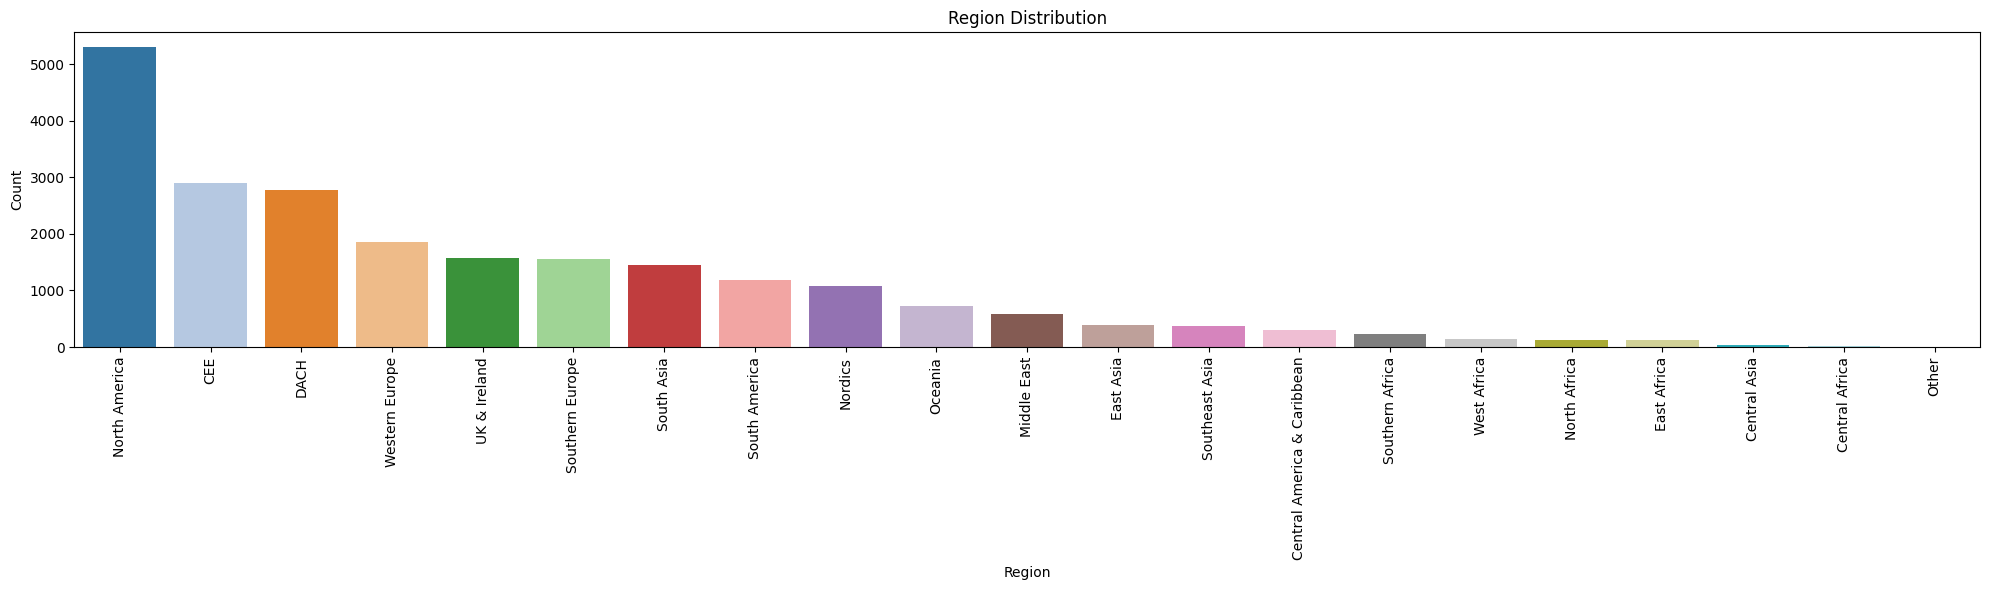

In [20]:
# Visualizing the distribution of regions among respondents
plt.figure(figsize=(20, 6))

palette = sns.color_palette("tab20", n_colors=df_plot["Region"].nunique())

sns.countplot(data=df_plot, x="Region", order=df_plot["Region"].value_counts().index, palette=palette)
plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Region Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

Mostly responders are from: 
- North America
- Central Eastern Europe
- DACH

The least popular regions: Africa.

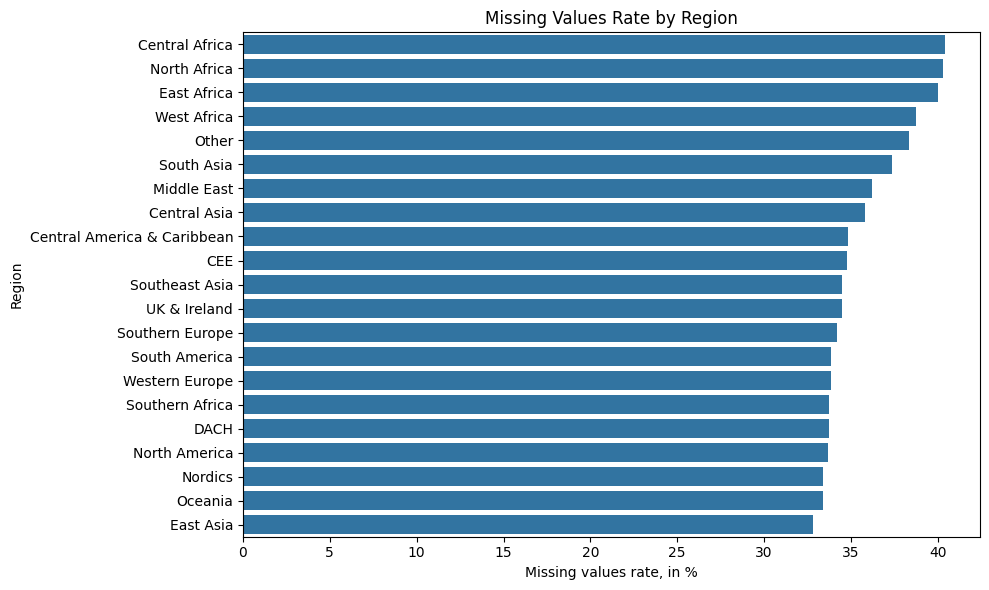

In [21]:
# Calculating the missing values rate for each region
missing_rate_all = df_plot.groupby("Region").apply(lambda x: x.isna().mean().mean() * 100)
missing_rate_all = missing_rate_all.sort_values(ascending=False)


plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_rate_all.values,
    y=missing_rate_all.index
)

plt.xlabel("Missing values rate, in %")
plt.ylabel("Region")
plt.title("Missing Values Rate by Region")
plt.tight_layout()
plt.show()

Responders from Africa region left the most missinf data.

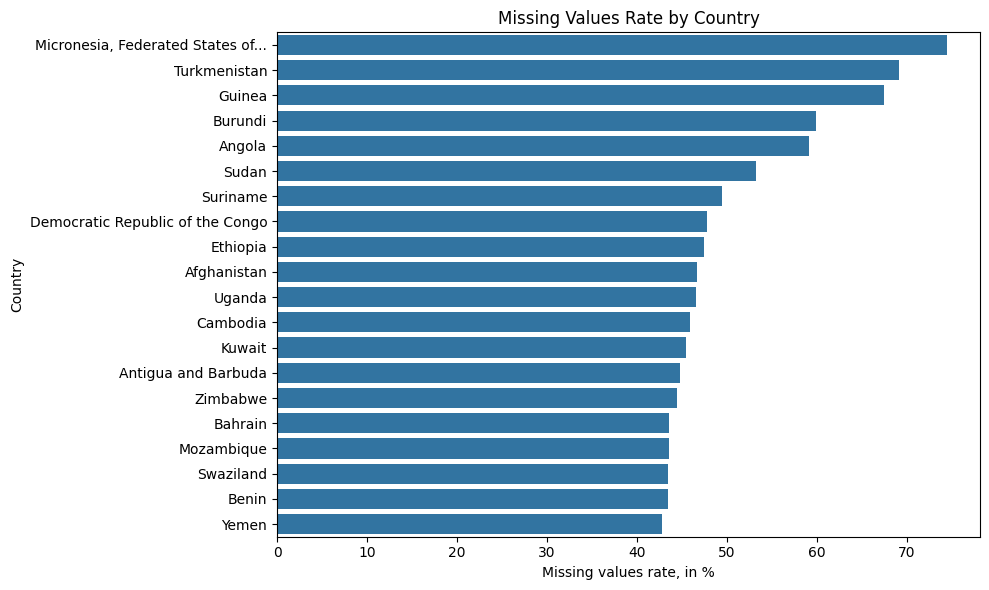

In [22]:
missing_rate_country = df_plot.groupby("Country").apply(lambda x: x.isna().mean().mean() * 100)
missing_rate_country = missing_rate_country.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_rate_country.head(20).values,
    y=missing_rate_country.head(20).index
)

plt.xlabel("Missing values rate, in %")
plt.ylabel("Country")
plt.title("Missing Values Rate by Country")
plt.tight_layout()
plt.show()

Countries with the least responses are: 
- Micronesia
- Turkmenistan
- Guinea
- Burundi
- Angola

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\622624140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Region", y="ConvertedCompYearly", palette=palette, order=df_plot.groupby("Region")["ConvertedCompYearly"].median().sort_values(ascending=False).index)


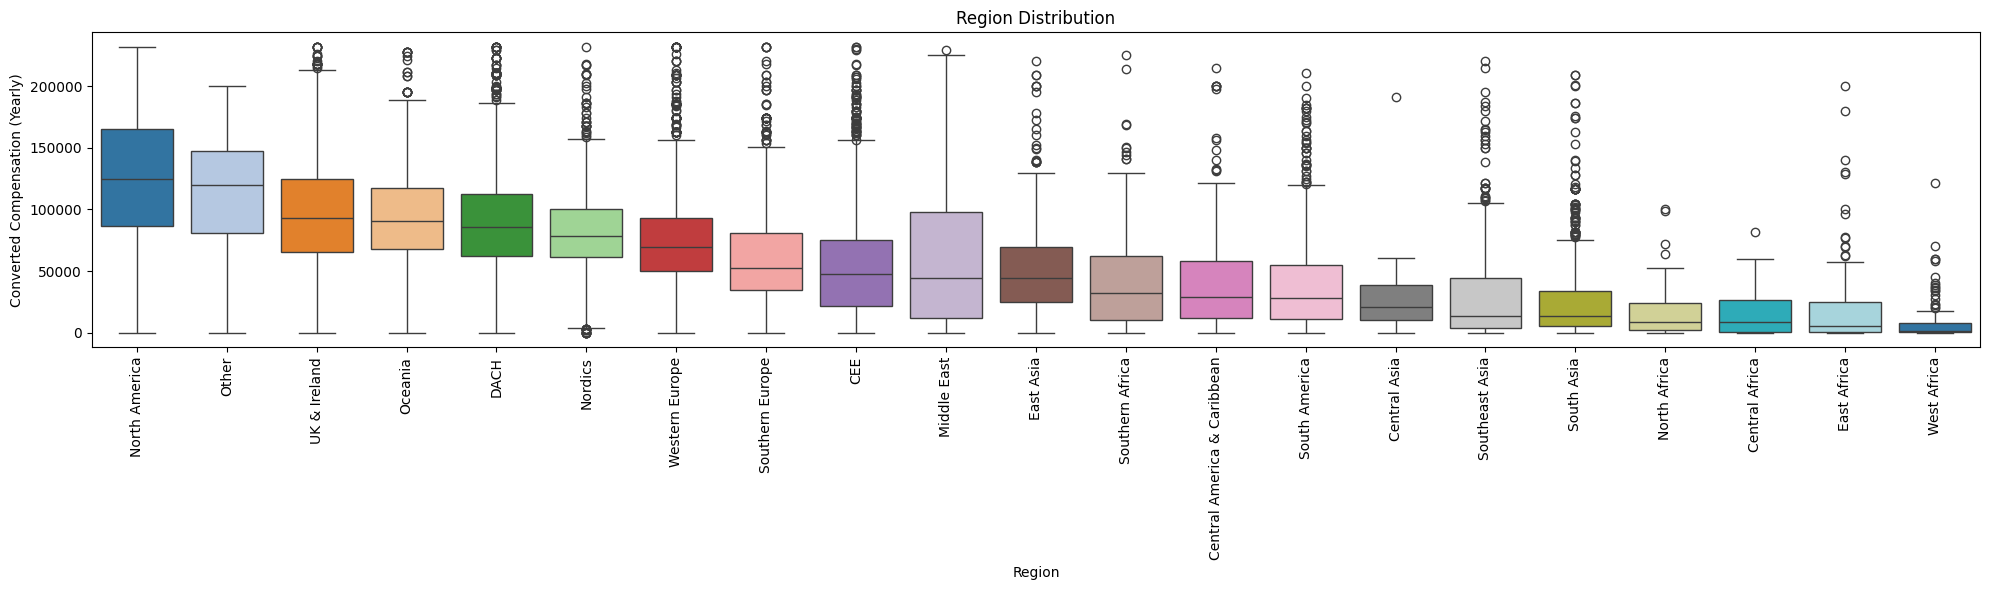

In [23]:
# Visualizing the salary among different regions
plt.figure(figsize=(20, 6))

palette = sns.color_palette("tab20", n_colors=df_plot["Region"].nunique())

sns.boxplot(data=df_plot, x="Region", y="ConvertedCompYearly", palette=palette, order=df_plot.groupby("Region")["ConvertedCompYearly"].median().sort_values(ascending=False).index)
plt.xlabel("Region")
plt.ylabel("Converted Compensation (Yearly)")
plt.title("Region Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

The highest median salary is observed in the North America region, followed by UK & Ireland and Oceania. DACH has 5th place, followed by Nordics. The lowest salaries are in Africa. The "Other" region with Nomadic as a country has to be investigated.

#### **4. Main Branch**

In [24]:
# Displaying the value counts for the "MainBranch"
df_plot["MainBranch"].value_counts()

MainBranch
I am a developer by profession                                                                19187
I am not primarily a developer, but I write code sometimes as part of my work/studies          2095
I used to be a developer by profession, but no longer am                                        450
I work with developers or my work supports developers but am not a developer by profession      365
I am learning to code                                                                           361
I code primarily as a hobby                                                                     301
Name: count, dtype: int64

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\417292661.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


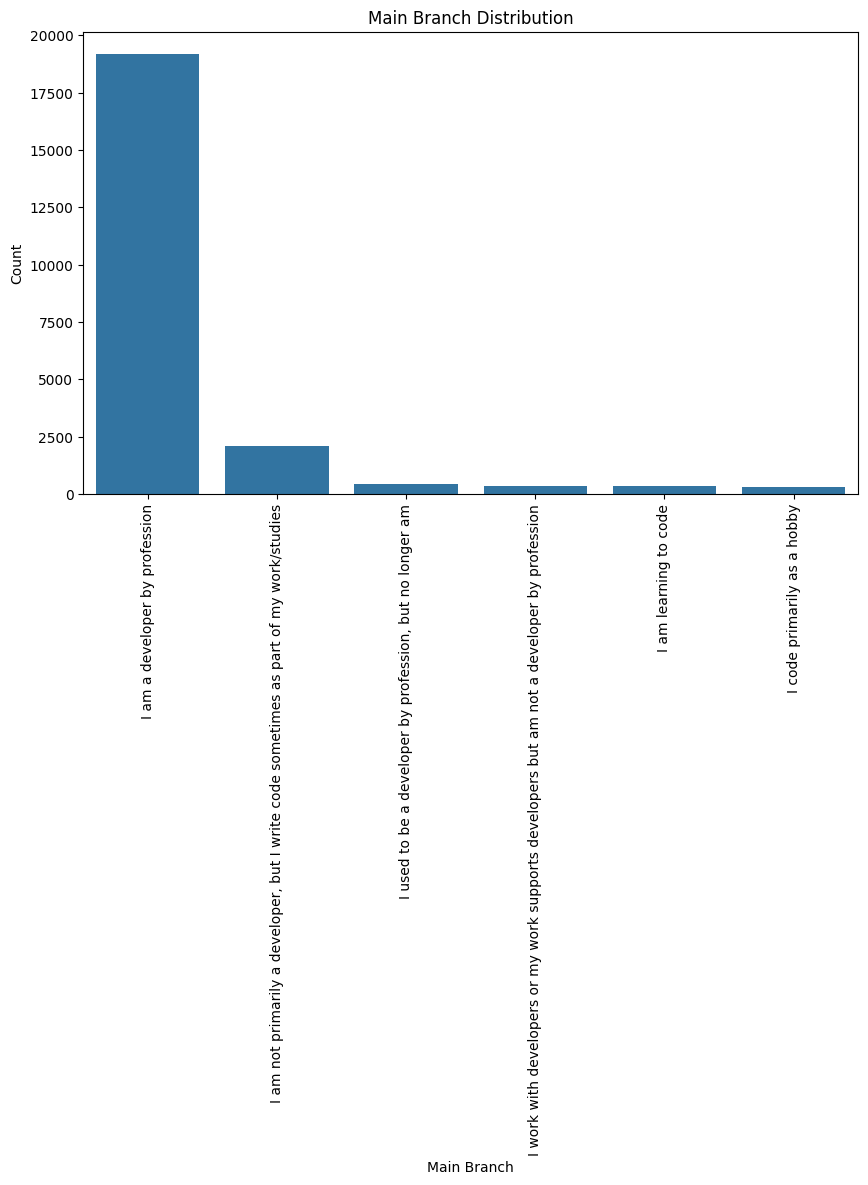

In [25]:
# Visualizing the distribution of main branches among respondents from all over the world
plt.figure(figsize=(10, 6))
sns.countplot(data=df_plot, x="MainBranch", order=df_plot["MainBranch"].value_counts().index)
plt.xlabel("Main Branch")
plt.ylabel("Count")
plt.title("Main Branch Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

Around 19K of responders are devs by profession, another 2K are not devs but still code.

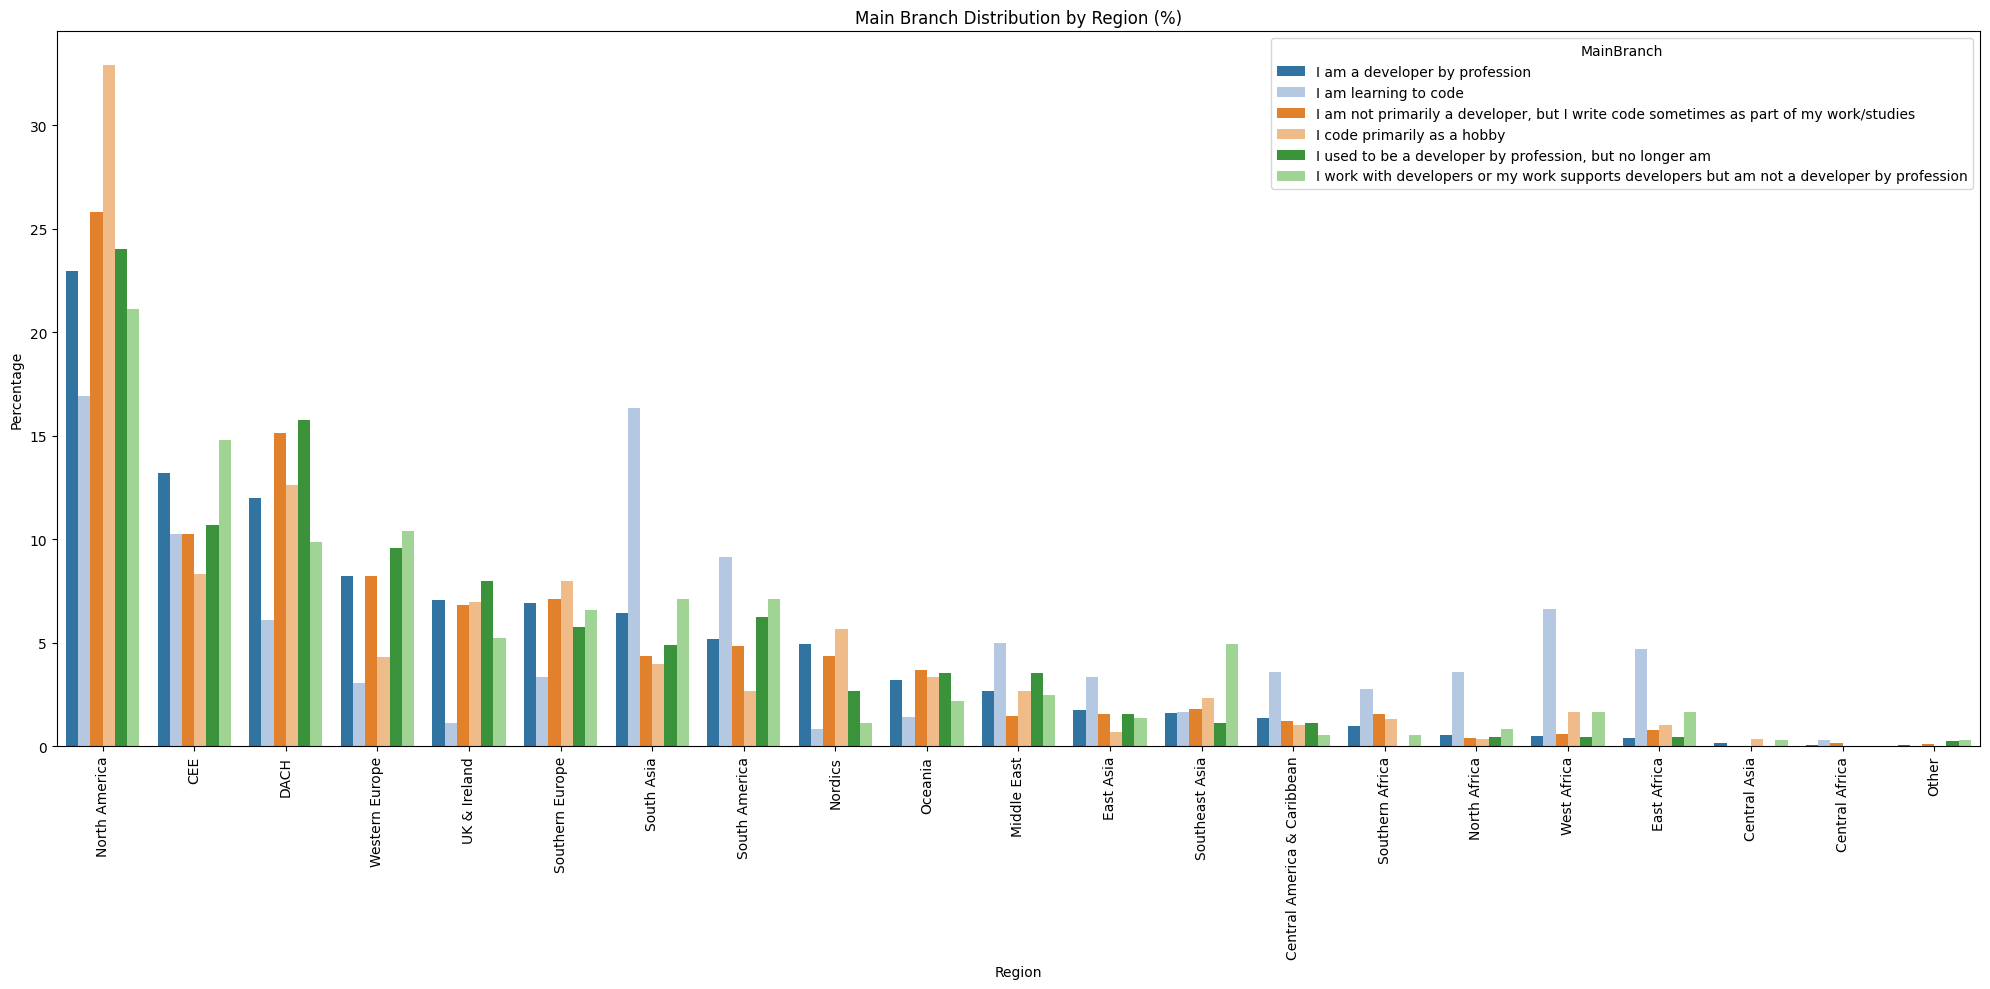

In [26]:
# Visualizing the distribution of main branches among respondents for different regions
role_dist = (
    df_plot.groupby("MainBranch")["Region"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

plt.figure(figsize=(20, 10))

sns.barplot(
    data=role_dist,
    x="Region",
    y="Percentage",
    hue="MainBranch",
    palette="tab20"
)

plt.xticks(rotation=90)
plt.title("Main Branch Distribution by Region (%)")
plt.tight_layout()
plt.show()


Top regions with devs by proffesion:
- North America
- CEE
- DACH

Top regions with responders who code as a part of job:
- North America
- DACH
- CEE

Top regions where responders are learning to code:
- North America
- South Asia
- CEE

Top regions with responders who used to be a developer:
- North America
- DACH
- CEE

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\3648091280.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


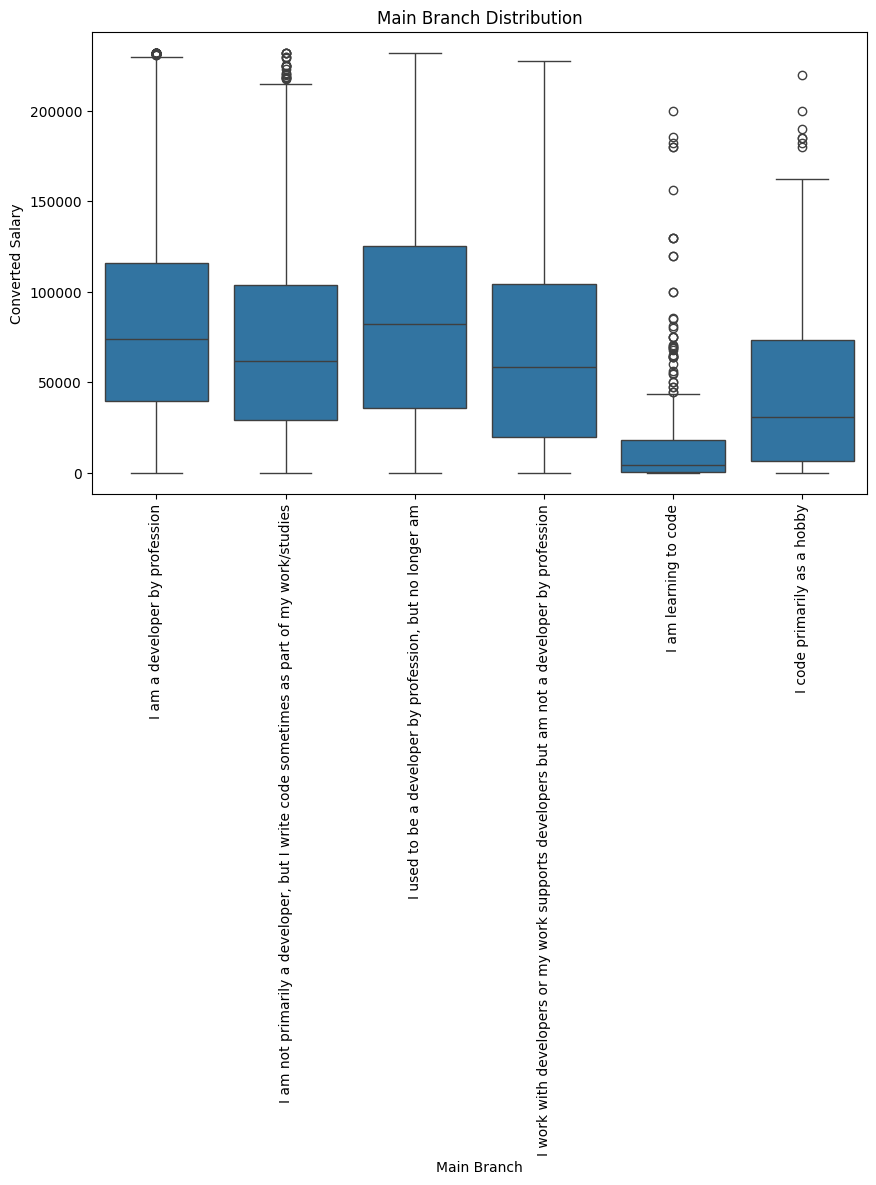

In [27]:
# Visualizing the salary distributions from all over the world
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x="MainBranch", y="ConvertedCompYearly", order=df_plot["MainBranch"].value_counts().index)
plt.xlabel("Main Branch")
plt.ylabel("Converted Salary")
plt.title("Main Branch Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

The highest salaries have devs and people who used to be devs. Probably because they switched to managers positions.

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\4274454504.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


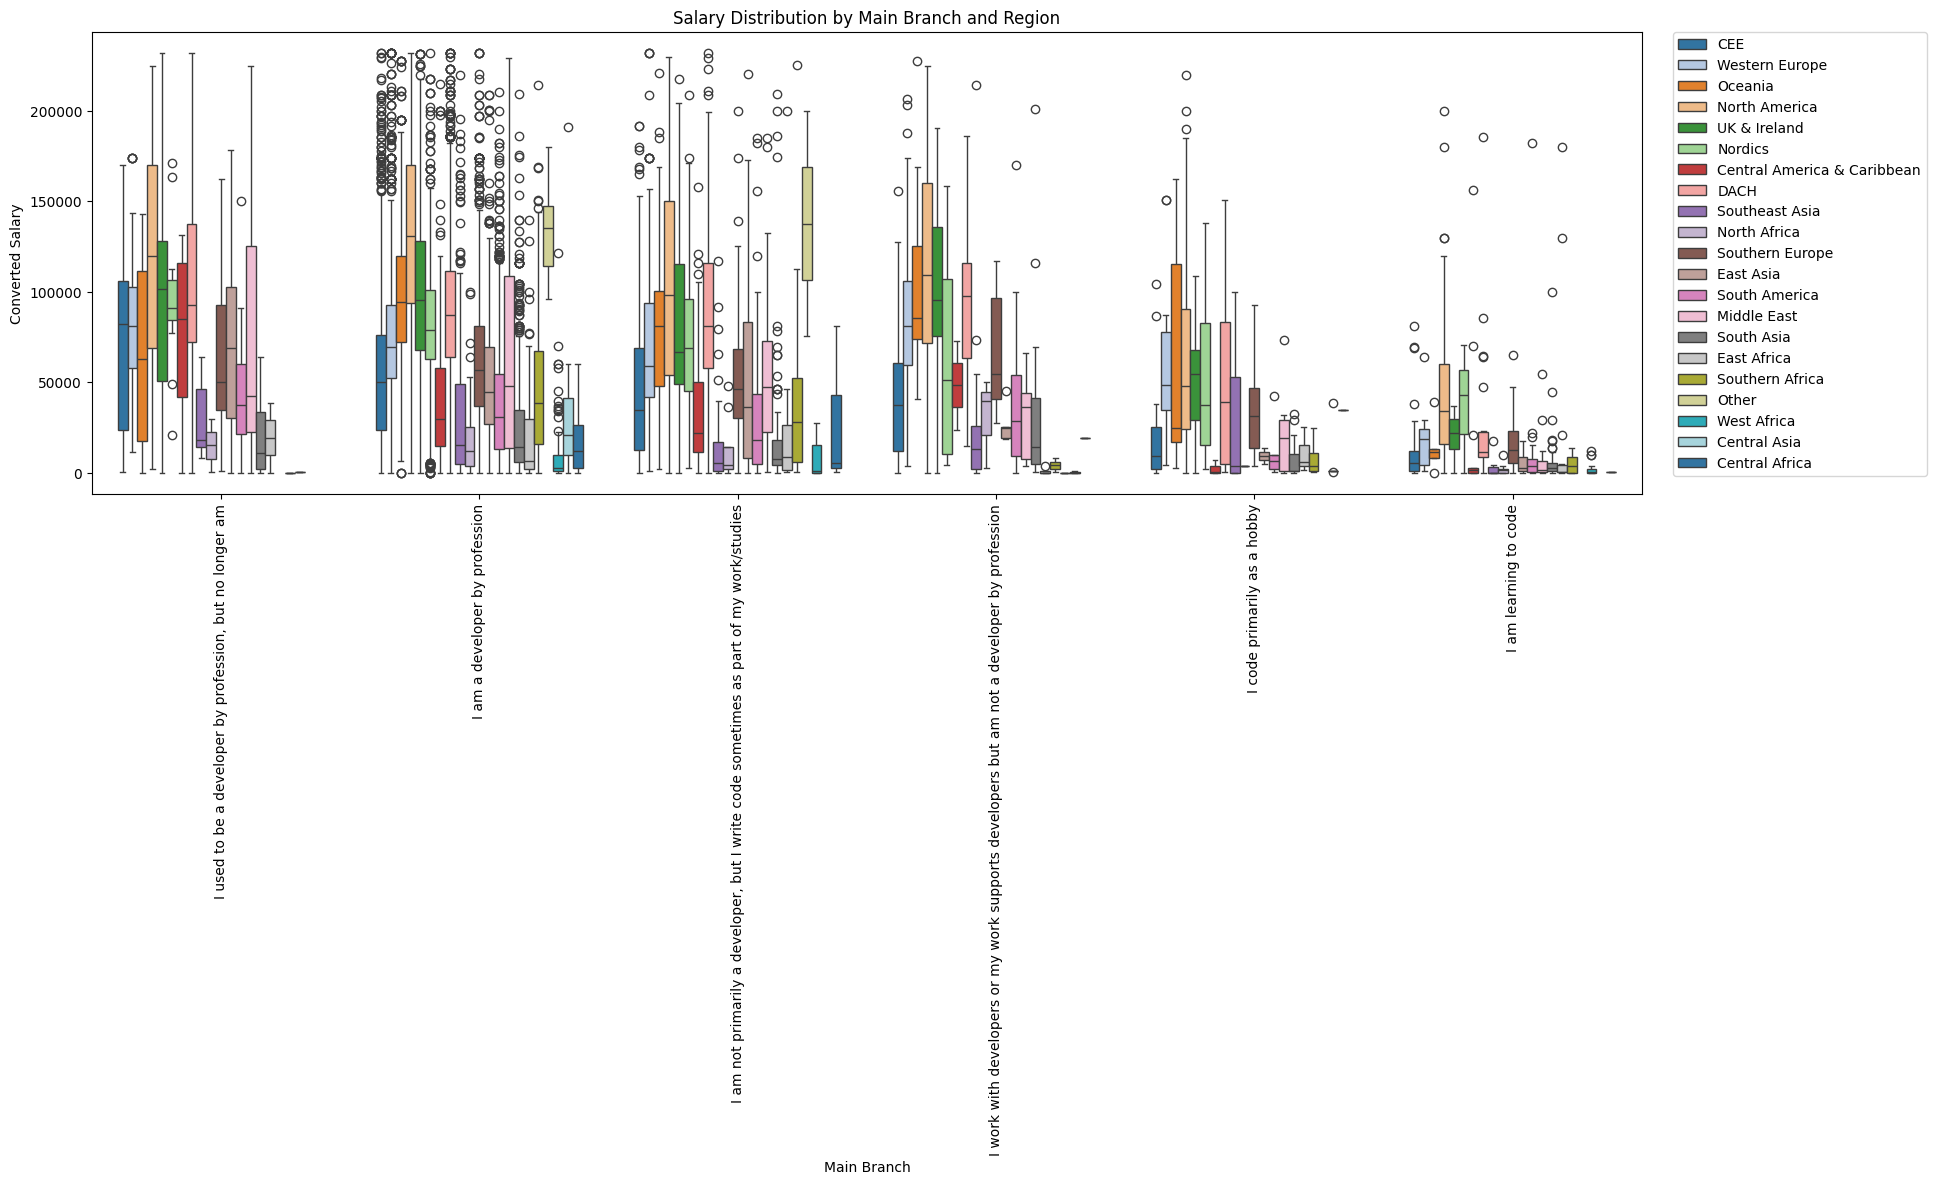

In [28]:
# Visualizing the salary distributions in different regions for different main branches
plt.figure(figsize=(20, 6))
ax = sns.boxplot(data=df_plot, x="MainBranch", y="ConvertedCompYearly", order=df_plot.groupby("MainBranch")["ConvertedCompYearly"].median().sort_values(ascending=False).index, hue="Region", palette="tab20")
ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
)
plt.xlabel("Main Branch")
plt.ylabel("Converted Salary")
plt.title("Salary Distribution by Main Branch and Region")
plt.xticks(rotation=90)
plt.tight_layout()

Devs have the highest salaries in:
- North America
- UK & Ireland
- Oceania
- DACH
- Nordics

People who used to be devs have the highest salaries in:
- North America
- UK & Ireland
- DACH
- Nordics
- Central America 

People who codes sometime as a part of work sudies have the highest salaries in:
- North America
- Oceania
- DACH
- Nordics
- UK & Ireland

People who support devs have the highest salaries in:
- North America
- DACH
- UK & Ireland
- Oceania
- Western Europe

People who code as a hobby or are learning to code have low salaries in general.

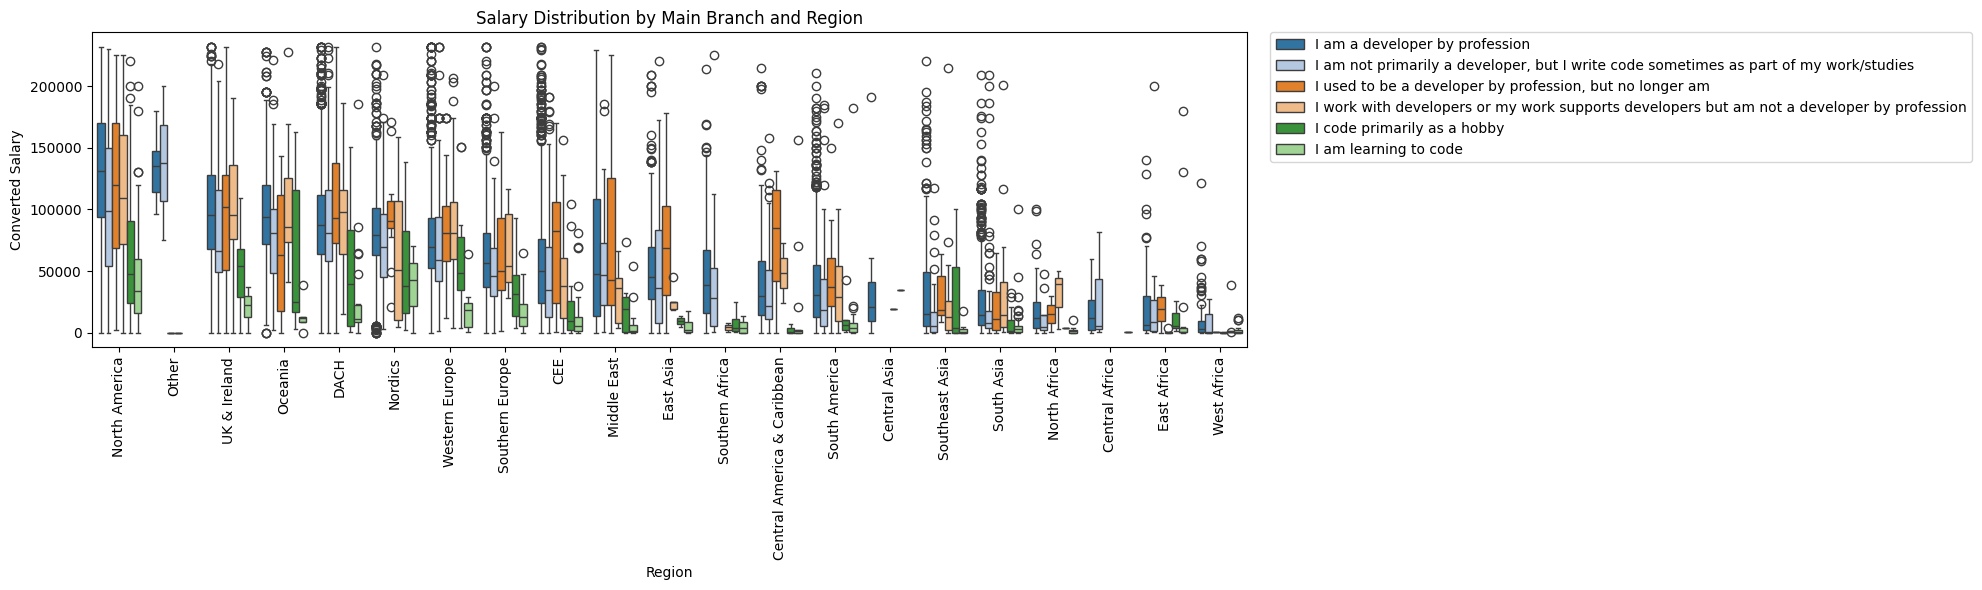

In [29]:
# Visualizing the salary distributions in different regions for different main branches
plt.figure(figsize=(20, 6))
ax = sns.boxplot(data=df_plot, x="Region", y="ConvertedCompYearly", order=df_plot.groupby("Region")["ConvertedCompYearly"].median().sort_values(ascending=False).index, hue="MainBranch", palette="tab20")
ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
)
plt.xlabel("Region")
plt.ylabel("Converted Salary")
plt.title("Salary Distribution by Main Branch and Region")
plt.xticks(rotation=90)
plt.tight_layout()

In North America, Oceania, Middle East highest salaries have devs. 
In other regions people who used to be devs.

#### **5. Age**

In [30]:
# Displaying the value counts for the "Age" column
df_plot["Age"].value_counts()

Age
25-34 years old      8310
35-44 years old      7087
45-54 years old      3183
18-24 years old      2566
55-64 years old      1284
65 years or older     309
Prefer not to say      20
Name: count, dtype: int64

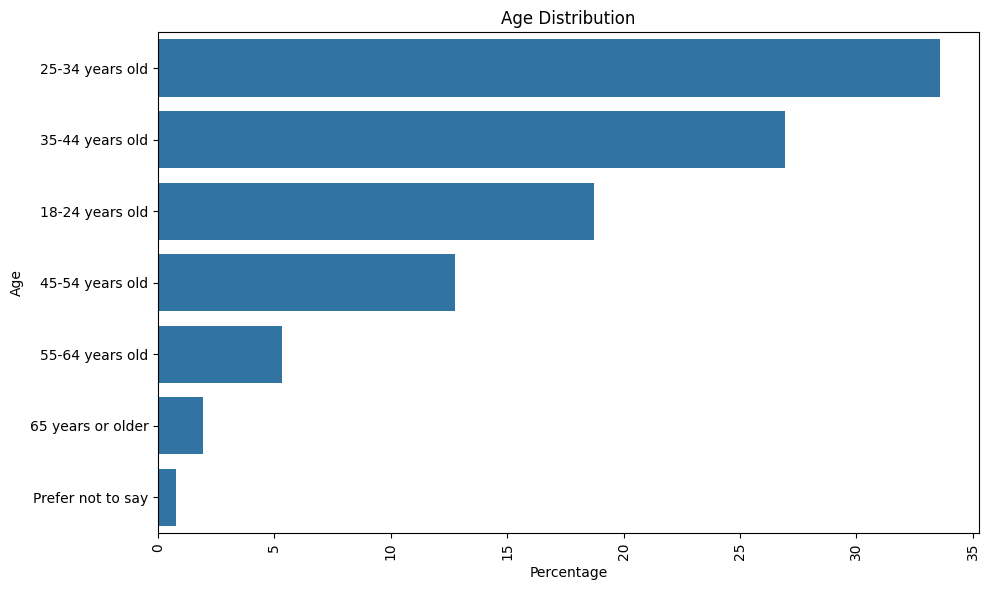

In [36]:
# Visualizing the distribution of age categories among respondents from all over the world
age_rate = df["Age"].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_rate.values,
    y=age_rate.index
)

plt.xlabel("Percentage")
plt.ylabel("Age")
plt.title("Age Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

Mostly responders are in age group 25-44 years old.

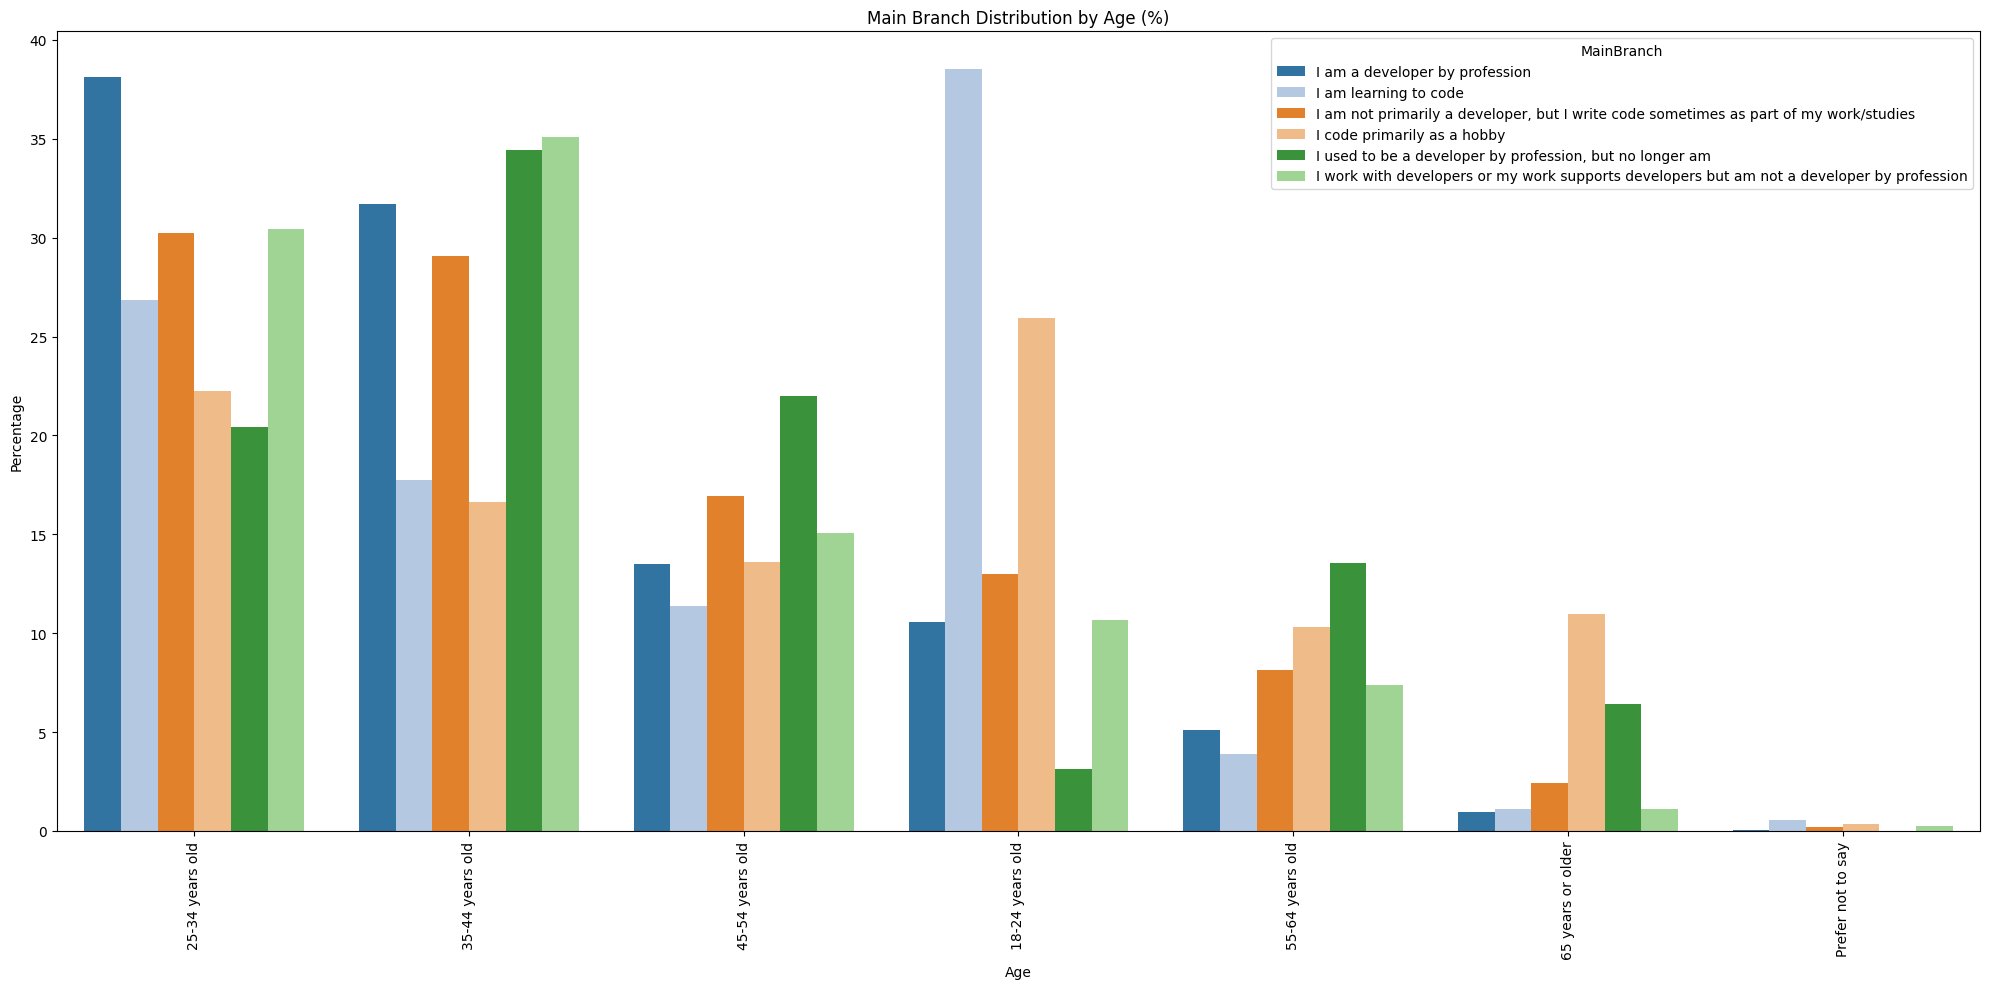

In [38]:
# Visualizing the distribution of different branches among respondents for different age categories
role_age_dist = (
    df_plot.groupby("MainBranch")["Age"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

plt.figure(figsize=(20, 10))

sns.barplot(
    data=role_age_dist,
    x="Age",
    y="Percentage",
    hue="MainBranch",
    palette="tab20"
)

plt.xticks(rotation=90)
plt.title("Main Branch Distribution by Age (%)")
plt.tight_layout()
plt.show()


Responders in age group 18-24 

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\3648091280.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


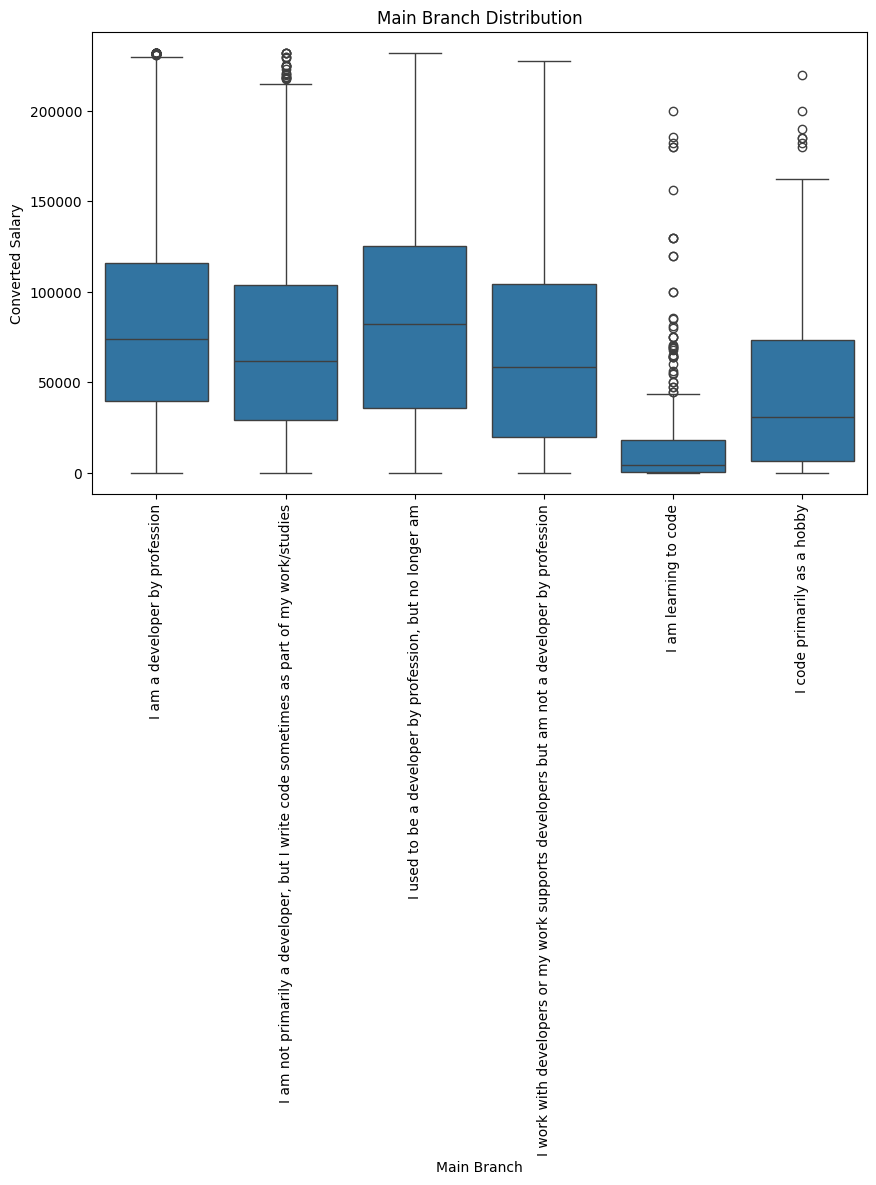

In [ ]:
# Visualizing the salary distributions from all over the world
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x="MainBranch", y="ConvertedCompYearly", order=df_plot["MainBranch"].value_counts().index)
plt.xlabel("Main Branch")
plt.ylabel("Converted Salary")
plt.title("Main Branch Distribution")
plt.xticks(rotation=90)
plt.tight_layout()

The highest salaries have devs and people who used to be devs. Probably because they switched to managers positions.

C:\Users\tetya\AppData\Local\Temp\ipykernel_26468\4274454504.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


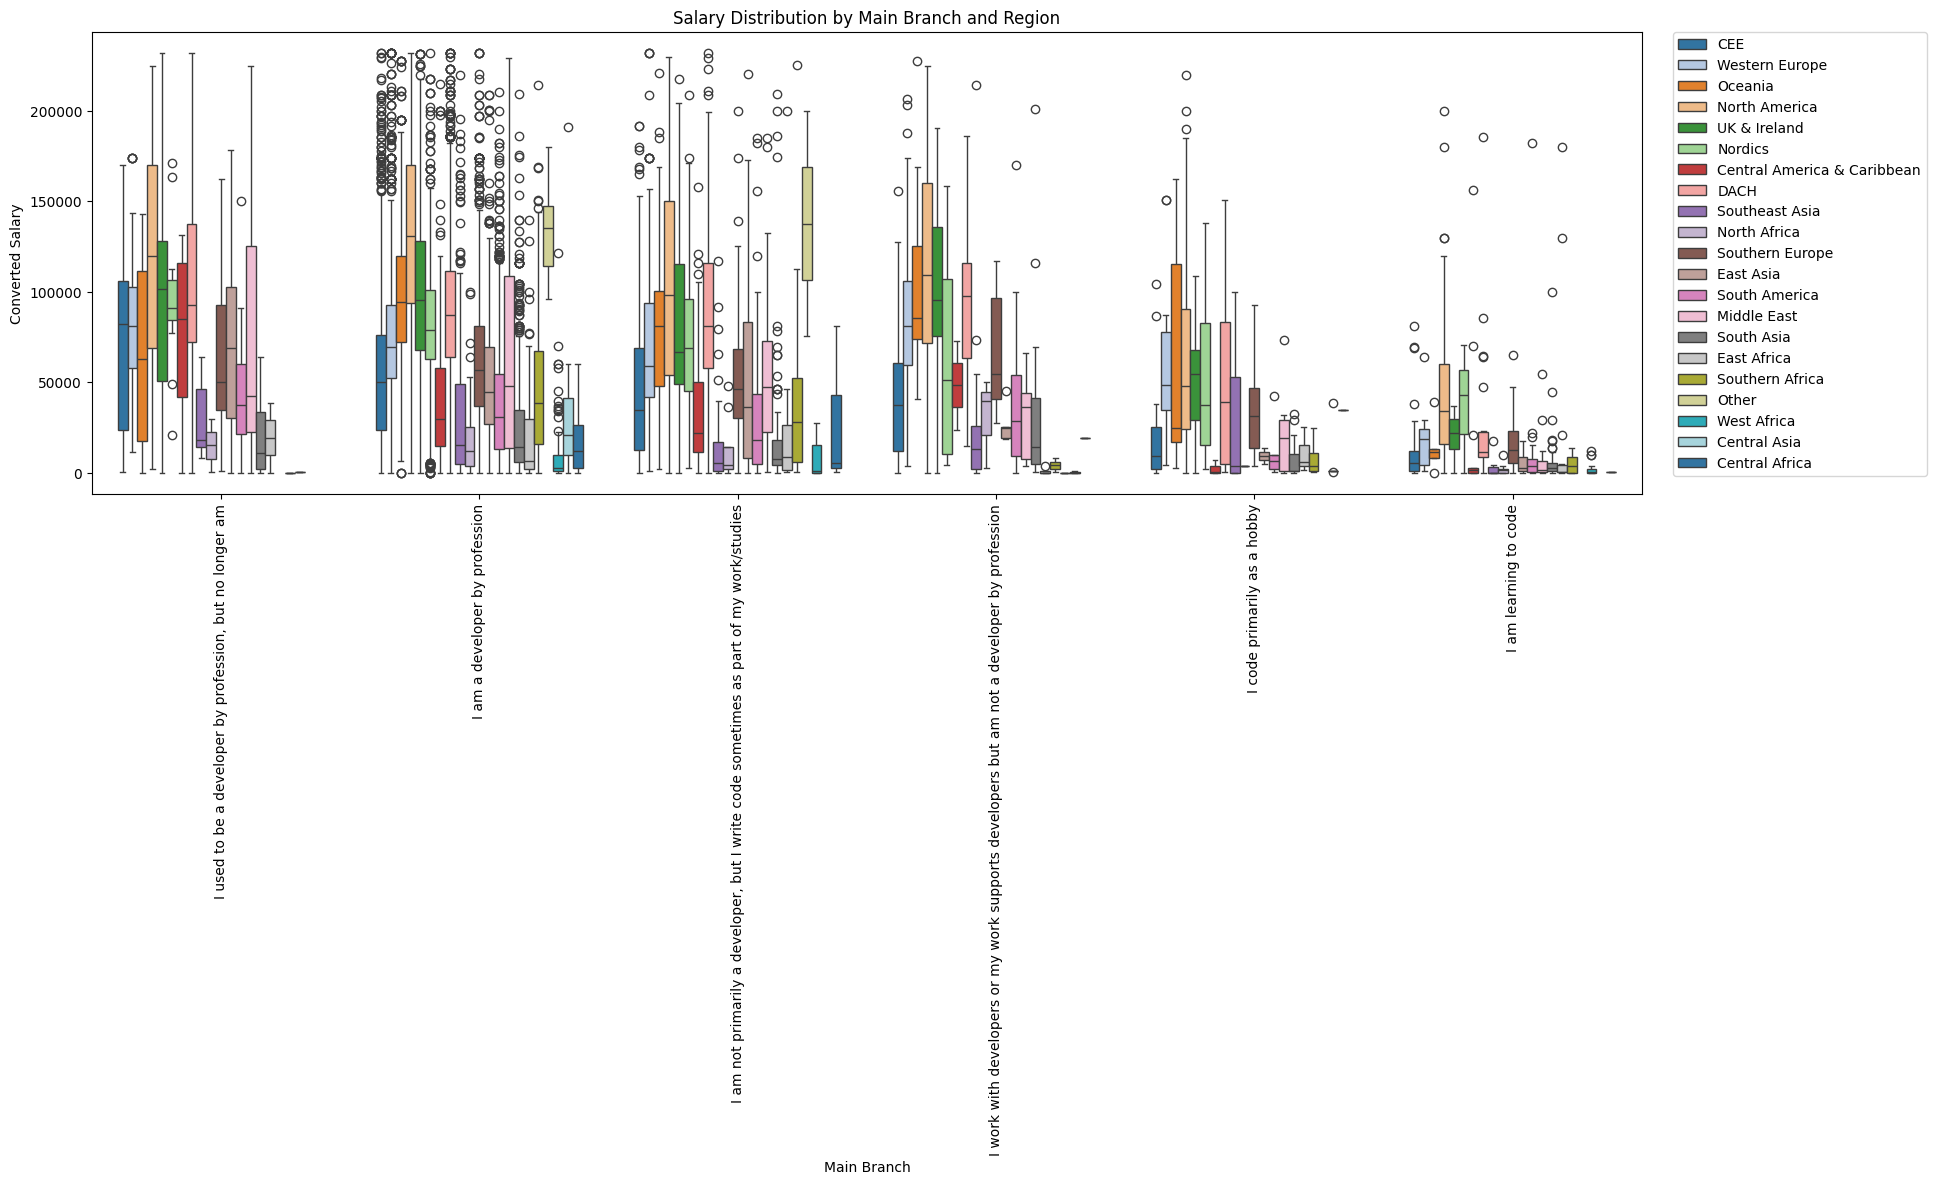

In [ ]:
# Visualizing the salary distributions in different regions for different main branches
plt.figure(figsize=(20, 6))
ax = sns.boxplot(data=df_plot, x="MainBranch", y="ConvertedCompYearly", order=df_plot.groupby("MainBranch")["ConvertedCompYearly"].median().sort_values(ascending=False).index, hue="Region", palette="tab20")
ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
)
plt.xlabel("Main Branch")
plt.ylabel("Converted Salary")
plt.title("Salary Distribution by Main Branch and Region")
plt.xticks(rotation=90)
plt.tight_layout()

Devs have the highest salaries in:
- North America
- UK & Ireland
- Oceania
- DACH
- Nordics

People who used to be devs have the highest salaries in:
- North America
- UK & Ireland
- DACH
- Nordics
- Central America 

People who codes sometime as a part of work sudies have the highest salaries in:
- North America
- Oceania
- DACH
- Nordics
- UK & Ireland

People who support devs have the highest salaries in:
- North America
- DACH
- UK & Ireland
- Oceania
- Western Europe

People who code as a hobby or are learning to code have low salaries in general.

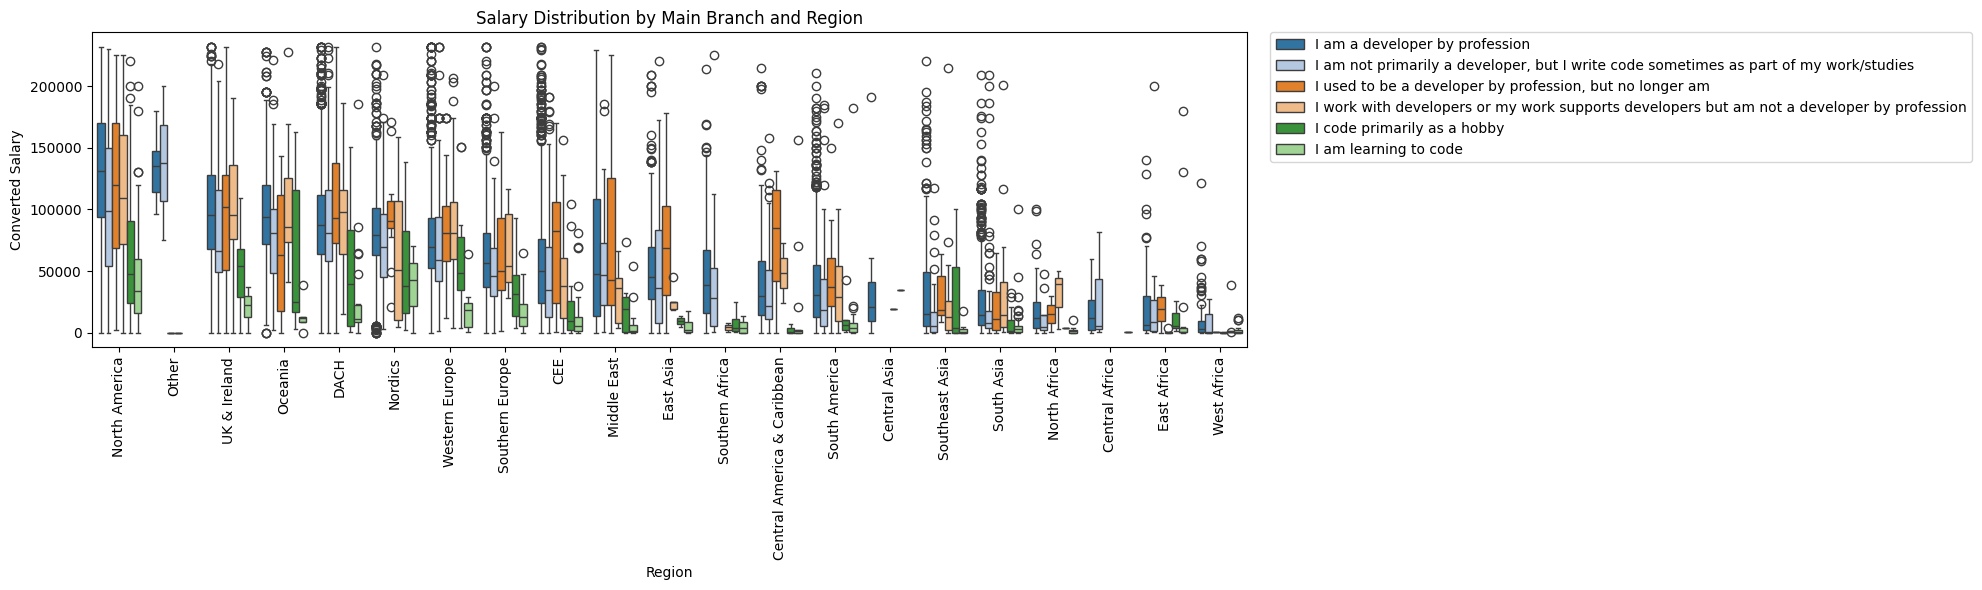

In [ ]:
# Visualizing the salary distributions in different regions for different main branches
plt.figure(figsize=(20, 6))
ax = sns.boxplot(data=df_plot, x="Region", y="ConvertedCompYearly", order=df_plot.groupby("Region")["ConvertedCompYearly"].median().sort_values(ascending=False).index, hue="MainBranch", palette="tab20")
ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
)
plt.xlabel("Region")
plt.ylabel("Converted Salary")
plt.title("Salary Distribution by Main Branch and Region")
plt.xticks(rotation=90)
plt.tight_layout()

In North America, Oceania, Middle East highest salaries have devs. 
In other regions people who used to be devs.